In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd

df = pd.read_csv('../data/raw_superstore.csv')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [7]:
df['sales'] = df['sales'].str.replace(',', '').astype(float)

In [8]:
df['sales'].dtype

dtype('float64')

In [9]:
df.groupby('sub_category')['profit'].sum().sort_values().head(10)

sub_category
Tables        -64083.3887
Fasteners      11525.4241
Labels         15010.5120
Supplies       22583.2631
Envelopes      29601.1163
Furnishings    46967.4255
Art            57953.9109
Machines       58867.8730
Paper          59207.6827
Binders        72449.8460
Name: profit, dtype: float64

In [10]:
#I verified my pandas result matched my SQL result independently

In [11]:
import numpy as np

df['discount_band'] = pd.cut(df['discount'],
                               bins=[-0.01, 0, 0.1, 0.2, 0.3, 1.0],
                               labels=['0%', '1-10%', '11-20%', '21-30%', '30%+'])

df.groupby(['sub_category', 'discount_band'])['profit'].sum().unstack()

discount_band,0%,1-10%,11-20%,21-30%,30%+
sub_category,,,,,
Accessories,149217.1839,9686.82900,8122.3498,NaN,-37400.05650
Appliances,151937.8861,33154.28080,14678.1607,NaN,-58089.73820
Art,73528.1906,3346.17000,1518.1416,-596.53710,-19842.05420
Binders,89849.2907,3012.35700,31493.8637,NaN,-51905.66540
Bookcases,187886.5917,57455.99940,7018.0017,-555.87260,-89880.30070
Chairs,152517.3461,50720.63890,11166.5150,-6952.94150,-65477.76100
Copiers,200437.2149,92327.22698,25743.5793,-595.27272,-59345.20028
Envelopes,36101.9744,1592.35500,2333.4846,NaN,-10426.69770
Fasteners,15943.4652,1021.29900,561.2234,NaN,-6000.56350


In [12]:
df.groupby('discount_band', observed=True)['profit'].sum()

discount_band
0%        1.770695e+06
1-10%     3.397668e+05
11-20%    1.732548e+05
21-30%   -2.115561e+04
30%+     -7.935265e+05
Name: profit, dtype: float64

In [13]:
## Key Finding
   Profit stays healthy up to 20% discount, turns negative at 21-30%, 
   and becomes severe (-$793k) at 30%+ discount. This pattern holds 
   across every sub-category. Tables is the only sub-category pushed 
   into overall negative profit, because it lacks the low-discount 
   profit cushion other categories have.

IndentationError: unexpected indent (2653237680.py, line 2)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

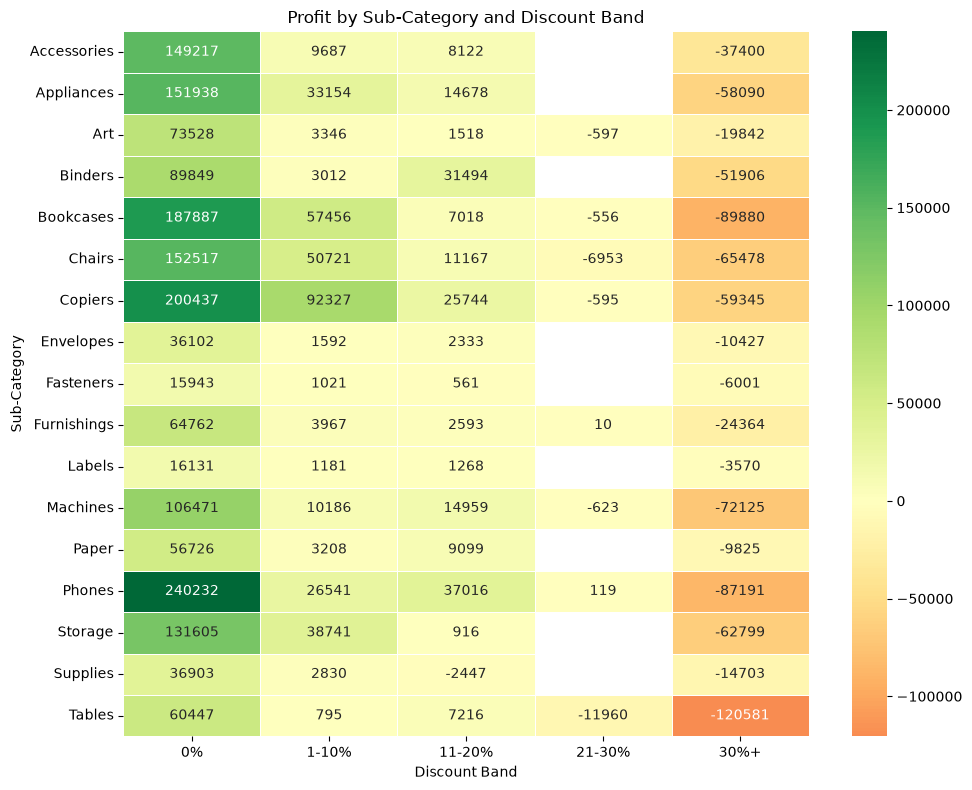

In [14]:
import seaborn as sns

pivot = df.groupby(['sub_category', 'discount_band'], observed=True)['profit'].sum().unstack()

plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Profit by Sub-Category and Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.savefig('../images/subcategory_discount_heatmap.png')
plt.show()